# MolAnchor Generation and Explanations

This notebook demonstrates how to generate MolAnchor explanations for compound selectivity models in this repository.

It includes:
- Optional end-to-end training (dataset -> features -> split -> model)
- Single-compound MolAnchor explanation
- Batch MolAnchor analysis across correctly predicted compounds
- Recurrent anchor rule extraction and interpretation

## Workflow Overview

1. Configure paths and model settings.
2. Either train a new model or reuse existing split/model artifacts.
3. Select a correctly predicted compound for a target class.
4. Generate and visualize MolAnchor explanations.
5. Run batch analysis and identify recurrent anchor rules.

In [1]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

def find_workspace_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current] + list(current.parents):
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    raise FileNotFoundError("Could not locate workspace root with pyproject.toml and src/")

workspace_root = find_workspace_root(Path.cwd())
src_path = workspace_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Workspace root: {workspace_root}")
print(f"Using src path:   {src_path}")

Workspace root: C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability
Using src path:   C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\src


In [2]:
from chemagent.datasets.dataset_tools import (
    find_datasets,
    load_dataset,
    compute_features,
    split_dataset,
)
from chemagent.ml.training_tools import train_model, check_training
from chemagent.explainability.molanchor_tools import (
    get_molanchor_info,
    select_compound_for_xai,
    explain_with_molanchor,
    explain_batch_with_molanchor,
    identify_recurrent_anchor_rules,
)

_ = get_molanchor_info()
print("MolAnchor tools imported successfully.")

MolAnchor tools imported successfully.


In [3]:
# -------------------- User Configuration --------------------
USE_EXISTING_ARTIFACTS = True

# If training a new model, choose a dataset CSV in data/datasets
dataset_csv = "data/datasets/chembl_activity_data_P14416_binary.csv"

# Featurization settings (must match explanation settings later)
n_bits = 2048
radius = 2

# Split/train settings
algorithm = "RFC"
task = "classification"
train_size, val_size, test_size = 0.7, 0.0, 0.3
seed = 42

# Explanation settings
target_class = 1
analysis_split = "test"
cutoff = 0.95
allow_frag_combinations = True
return_multiple_anchors = False
acc_for_radius = False

# Optional fallback artifact paths (used if auto-discovery fails)
manual_split_file_path = None
manual_model_path = None

output_dir = workspace_root / "notebooks" / "debug_outputs"
output_dir.mkdir(parents=True, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


In [4]:
def latest_file(pattern: str) -> str | None:
    matches = list(workspace_root.glob(pattern))
    if not matches:
        return None
    return str(max(matches, key=lambda p: p.stat().st_mtime))

if USE_EXISTING_ARTIFACTS:
    split_file_path = latest_file("data/logs/session_*/splits/*.pkl") or manual_split_file_path
    model_path = latest_file("data/logs/session_*/models/*.pkl") or manual_model_path

    if not split_file_path or not model_path:
        raise FileNotFoundError(
            "Could not auto-discover split/model artifacts. "
            "Set USE_EXISTING_ARTIFACTS=False to train, or set manual_* paths."
        )

    print("Using existing artifacts:")
    print("split_file_path =", split_file_path)
    print("model_path      =", model_path)
else:
    available = find_datasets()
    print("Available datasets:")
    print(available)

    load_info = load_dataset(file_path=dataset_csv)
    dataset_id = load_info["dataset_id"]
    print("Loaded dataset_id:", dataset_id)

    feat_info = compute_features(dataset_id=dataset_id, method="ECFP", n_bits=n_bits, radius=radius)
    print("Feature summary:", feat_info)

    split_info = split_dataset(
        dataset_id=dataset_id,
        split_type="random",
        train_size=train_size,
        val_size=val_size,
        test_size=test_size,
        seed=seed,
        stratified=True,
    )
    split_file_path = split_info["saved_to"]
    print("Split file:", split_file_path)

    job = train_model(
        split_file_path=split_file_path,
        algorithm=algorithm,
        task=task,
        opt_metric="balanced_accuracy",
        random_seed=seed,
    )
    print("Training job submitted:", job)

    while True:
        status = check_training(job["job_id"], model_save_path=job["model_save_path"])
        print(status["status"], "elapsed:", status.get("elapsed_seconds", "n/a"))
        if status["status"] in {"completed", "failed"}:
            break
        time.sleep(30)

    if status["status"] != "completed":
        raise RuntimeError(f"Training failed: {status}")

    model_path = status.get("model_path") or status.get("result", {}).get("model_path") or job["model_save_path"]
    print("Model path:", model_path)

Using existing artifacts:
split_file_path = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260422_110838_b94e93\splits\chembl_activity_data_P14416_binary_random.pkl
model_path      = C:\Users\janela\OneDrive - uni-bonn.de\Code\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_tiago_20260422_110838_b94e93\models\chembl_RFC.pkl


In [5]:
candidate = select_compound_for_xai(
    split_file_path=split_file_path,
    model_path=model_path,
    target_class=target_class,
    split=analysis_split,
    seed=seed,
)

candidate

{'smiles': 'COc1cccc(N2CCN(CCCCN3CCc4ccccc4C3=O)CC2)c1',
 'index': 2297,
 'true_label': 1,
 'predicted_label': 1,
 'prediction_confidence': 0.94,
 'split': 'test',
 'total_candidates': 1229,
 'status': 'completed'}

In [6]:
single_output_path = output_dir / "molanchor_single.png"

single_raw = explain_with_molanchor(
    smiles=candidate["smiles"],
    model_path=model_path,
    target_class=target_class,
    cutoff=cutoff,
    allow_frag_combinations=allow_frag_combinations,
    return_multiple_anchors=return_multiple_anchors,
    acc_for_radius=acc_for_radius,
    n_bits=n_bits,
    radius=radius,
    output_path=str(single_output_path),
)

single_meta = json.loads(single_raw[-1])
single_meta

anchors identified = {'frag_2'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]


{'smiles': 'COc1cccc(N2CCN(CCCCN3CCc4ccccc4C3=O)CC2)c1',
 'fragment_combinations': [{'Combination': ['frag_0'],
   'frag_0': 1,
   'frag_1': 0,
   'frag_2': 0,
   'frag_3': 0,
   'frag_4': 0},
  {'Combination': ['frag_1'],
   'frag_0': 0,
   'frag_1': 1,
   'frag_2': 0,
   'frag_3': 0,
   'frag_4': 0},
  {'Combination': ['frag_2'],
   'frag_0': 0,
   'frag_1': 0,
   'frag_2': 1,
   'frag_3': 0,
   'frag_4': 0},
  {'Combination': ['frag_3'],
   'frag_0': 0,
   'frag_1': 0,
   'frag_2': 0,
   'frag_3': 1,
   'frag_4': 0},
  {'Combination': ['frag_4'],
   'frag_0': 0,
   'frag_1': 0,
   'frag_2': 0,
   'frag_3': 0,
   'frag_4': 1},
  {'Combination': ['frag_0', 'frag_1'],
   'frag_0': 1,
   'frag_1': 1,
   'frag_2': 0,
   'frag_3': 0,
   'frag_4': 0},
  {'Combination': ['frag_0', 'frag_2'],
   'frag_0': 1,
   'frag_1': 0,
   'frag_2': 1,
   'frag_3': 0,
   'frag_4': 0},
  {'Combination': ['frag_0', 'frag_3'],
   'frag_0': 1,
   'frag_1': 0,
   'frag_2': 0,
   'frag_3': 1,
   'frag_4': 0},


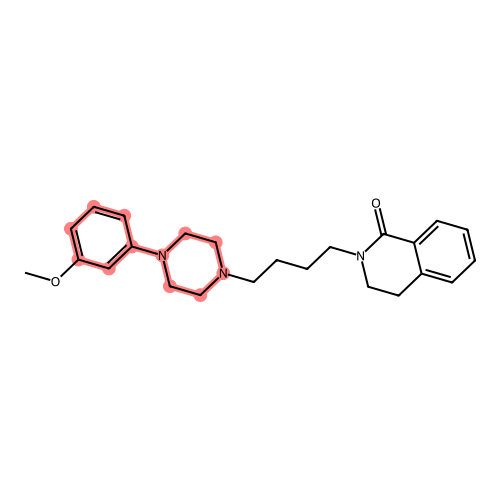

Anchor SMILES: ['[*]N1CCN([*])CC1']
Precision: 1.0
Fragments: 5


In [7]:
if "image_path" in single_meta and Path(single_meta["image_path"]).exists():
    display(Image(filename=single_meta["image_path"]))
else:
    print("No anchor image was generated for this compound.")

print("Anchor SMILES:", single_meta.get("anchor_smiles"))
print("Precision:", single_meta.get("precision"))
print("Fragments:", single_meta.get("num_fragments"))

In [8]:
batch_results = explain_batch_with_molanchor(
    split_file_path=split_file_path,
    model_path=model_path,
    target_class=target_class,
    split=analysis_split,
    cutoff=cutoff,
    allow_frag_combinations=allow_frag_combinations,
    return_multiple_anchors=return_multiple_anchors,
    acc_for_radius=acc_for_radius,
    n_bits=n_bits,
    radius=radius,
    max_compounds=25,
)

batch_results["aggregate_statistics"]

anchors identified = ['frag_0', 'frag_3'], num fragments = 5, plural_rule = True, Precision = [1.0], Coverage = [0.26]
anchors identified = {'frag_1'}, num fragments = 6, plural_rule = False, Precision = [0.97], Coverage = [0.49]
anchors identified = {'frag_4'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_3'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_2'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_3'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_3'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_5'}, num fragments = 7, plural_rule = False, Precision = [0.97], Coverage = [0.49]
anchors identified = {'frag_3'}, num fragments = 9, plural_rule = False, Precision = [1.0], Coverage = [0.5]


{'mean_num_fragments': 6.0,
 'mean_precision': 0.9924,
 'compounds_with_anchors': 25,
 'anchor_frequency': {'[*]S(=O)(=O)c1cccc2ncccc12||[*]N1CCN([*])CC1': 1,
  '[*]N1CCN([*])C1=O': 1,
  '[*]N1CCN(C)CC1': 1,
  '[*]N1CCN([*])CC1': 11,
  '[*]N1CCCN([*])CC1': 1,
  '[*]c1cc2c(cc1[*])C1Cc3ccc([*])c([*])c3CN1CC2': 1,
  '[*]N1CC=C(c2nc3ccccc3o2)CC1': 1,
  '[*]C1CCC([*])CC1||[*]N1CCC([*])CC1': 2,
  '[*]N1CC=C(c2ccccc2)CC1': 1,
  '[*]c1cccc([*])c1||[*]N1CCN([*])CC1': 1,
  '[*]CCC[*]||[*]c1cn(S(=O)(=O)c2ccccc2)c2ccccc12': 1,
  '[*]N1CCC([*])CC1': 1,
  '[*]N1CCC2(CCc3ccc(F)cc32)C1': 1,
  '[*]c1cc([*])nc([*])n1||[*]N1CCN([*])CC1': 1},
 'most_common_anchors': [{'anchor': '[*]N1CCN([*])CC1', 'frequency': 11},
  {'anchor': '[*]C1CCC([*])CC1||[*]N1CCC([*])CC1', 'frequency': 2},
  {'anchor': '[*]S(=O)(=O)c1cccc2ncccc12||[*]N1CCN([*])CC1', 'frequency': 1},
  {'anchor': '[*]N1CCN([*])C1=O', 'frequency': 1},
  {'anchor': '[*]N1CCN(C)CC1', 'frequency': 1}]}

In [9]:
rule_outputs = identify_recurrent_anchor_rules(
    split_file_path=split_file_path,
    model_path=model_path,
    target_class=target_class,
    split=analysis_split,
    cutoff=cutoff,
    allow_frag_combinations=allow_frag_combinations,
    return_multiple_anchors=return_multiple_anchors,
    acc_for_radius=acc_for_radius,
    n_bits=n_bits,
    radius=radius,
    top_n_anchors=5,
)

rule_json_items = [json.loads(item) for item in rule_outputs if isinstance(item, str)]
rule_summary = rule_json_items[-1]
rule_details = rule_json_items[:-1]

pd.DataFrame(rule_details)

anchors identified = {'frag_1'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_3'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_2'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_2'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = {'frag_1'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_2'}, num fragments = 7, plural_rule = False, Precision = [1.0], Coverage = [0.5]
anchors identified = {'frag_3'}, num fragments = 8, plural_rule = False, Precision = [0.98], Coverage = [0.49]
anchors identified = ['frag_0', 'frag_1'], num fragments = 8, plural_rule = True, Precision = [1.0], Coverage = [0.25]
anchors identified = {'frag_2'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
a

[15:42:49] SMARTS Parse Error: syntax error while parsing: all_frags
[15:42:49] SMARTS Parse Error: check for mistakes around position 2:
[15:42:49] all_frags
[15:42:49] ~^
[15:42:49] SMARTS Parse Error: Failed parsing SMARTS 'all_frags' for input: 'all_frags'


anchors identified = {'frag_2'}, num fragments = 5, plural_rule = False, Precision = [1.0], Coverage = [0.52]
anchors identified = {'frag_5'}, num fragments = 7, plural_rule = False, Precision = [0.97], Coverage = [0.49]
anchors identified = {'frag_1'}, num fragments = 4, plural_rule = False, Precision = [1.0], Coverage = [0.53]
anchors identified = ['frag_2', 'frag_4'], num fragments = 6, plural_rule = True, Precision = [1.0], Coverage = [0.25]
anchors identified = ['frag_0', 'frag_2'], num fragments = 7, plural_rule = True, Precision = [1.0], Coverage = [0.25]


,fragment,substructure_occurrence,anchor_occurrence,num_compounds_with_substructure,num_compounds_with_anchor,rank,image_path
0,[*]N1CCN([*])CC1,0.551668,0.427177,678,525,1,C:\Users\janela\OneDrive - uni-bonn.de\Code\AI...
1,[*]N1CCC([*])CC1,0.217250,0.044752,267,55,2,C:\Users\janela\OneDrive - uni-bonn.de\Code\AI...
2,[*]N1CCC([*])(O)CC1,0.039870,0.027665,49,34,3,C:\Users\janela\OneDrive - uni-bonn.de\Code\AI...
3,"[[*]C1CCC([*])CC1, [*]N1CCC([*])CC1]",0.061025,0.026851,75,33,4,C:\Users\janela\OneDrive - uni-bonn.de\Code\AI...
4,"[[*]c1nnc([*])n1C, [*]CCC[*]]",0.052075,0.020342,64,25,5,C:\Users\janela\OneDrive - uni-bonn.de\Code\AI...


In [11]:
rule_outputs 

 '{\n  "fragment": "[*]N1CCN([*])CC1",\n  "substructure_occurrence": 0.5516680227827502,\n  "anchor_occurrence": 0.42717656631407647,\n  "num_compounds_with_substructure": 678,\n  "num_compounds_with_anchor": 525,\n  "rank": 1,\n  "image_path": "C:\\\\Users\\\\janela\\\\OneDrive - uni-bonn.de\\\\Code\\\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\\\data\\\\logs\\\\session_tiago_20260422_110838_b94e93\\\\plots\\\\anchor_rule_1_tiago_20260422_110838_b94e93.png"\n}',
 '{\n  "fragment": "[*]N1CCC([*])CC1",\n  "substructure_occurrence": 0.21724979658258747,\n  "anchor_occurrence": 0.044751830756712775,\n  "num_compounds_with_substructure": 267,\n  "num_compounds_with_anchor": 55,\n  "rank": 2,\n  "image_path": "C:\\\\Users\\\\janela\\\\OneDrive - uni-bonn.de\\\\Code\\\\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\\\\data\\\\logs\\\\session_tiago_20260422_110838_b94e93\\\\plots\\\\anchor_rule_2_tiago_20260422_110838_b94e93.png"\n}',
 '{\n  "fragment": 

Rank 1 fragment: [*]N1CCN([*])CC1


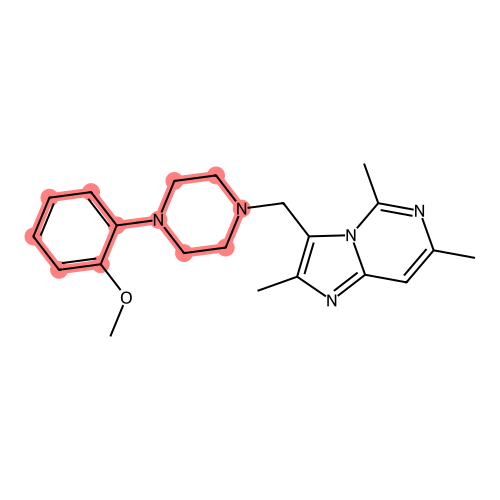

Rank 2 fragment: [*]N1CCC([*])CC1


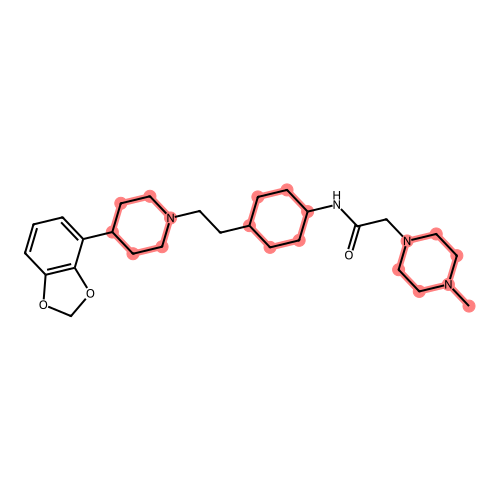

Rank 3 fragment: [*]N1CCC([*])(O)CC1


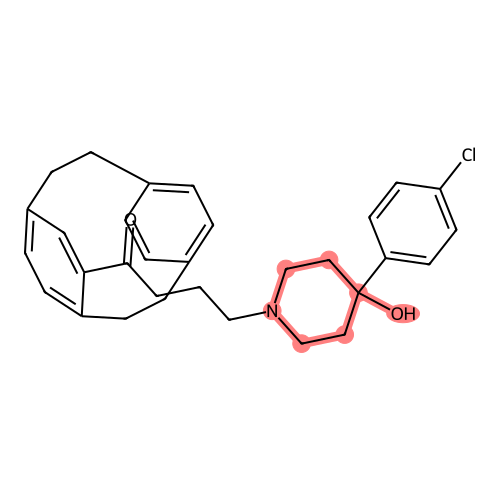

Rank 4 fragment: ['[*]C1CCC([*])CC1', '[*]N1CCC([*])CC1']


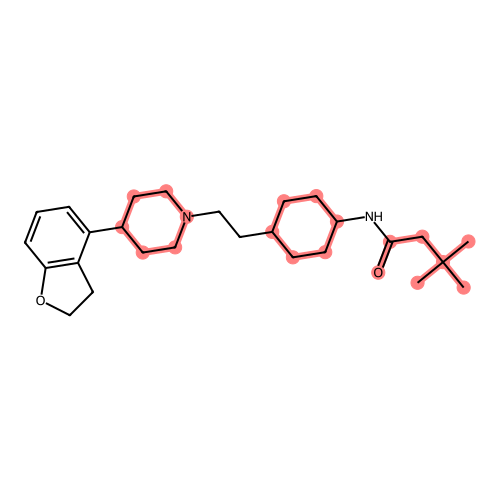

Rank 5 fragment: ['[*]c1nnc([*])n1C', '[*]CCC[*]']


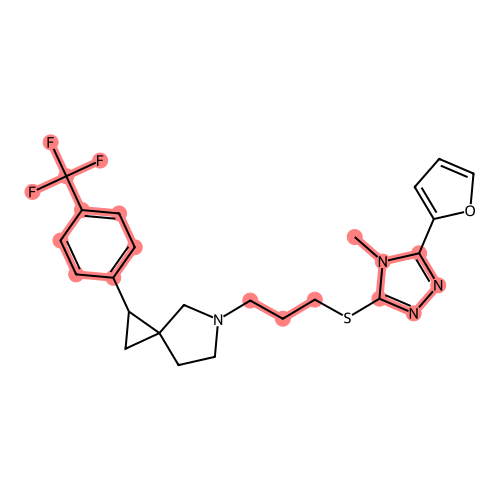

{'target_class': 1,
 'split': 'test',
 'num_analyzed_compounds': 1229,
 'total_unique_anchor_rules': 280,
 'top_n_rules_shown': 5,
 'status': 'completed'}

In [10]:
for rule in rule_details:
    if "image_path" in rule and Path(rule["image_path"]).exists():
        print("Rank", rule["rank"], "fragment:", rule["fragment"])
        display(Image(filename=rule["image_path"]))

rule_summary

## Interpretation Notes

- High `anchor_occurrence` means the fragment is frequently critical among analyzed compounds.
- Compare `anchor_occurrence` to `substructure_occurrence`:
  - Similar values can indicate a strong and specific rule.
  - Much lower anchor occurrence suggests the fragment is common but not consistently decisive.
- Keep `n_bits` and `radius` identical to model training settings for valid ECFP-based explanations.